## Instalando e Carregando os Pacotes

In [5]:
# Imports
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.formula.api import ols
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn import metrics
pd.options.mode.chained_assignment = None  
import warnings
warnings.filterwarnings("ignore")

## Carregando os Dados

In [6]:
# Carregando os dados
df = pd.read_csv('expectativa_vida.csv')

In [7]:
# Shape
df.shape

(2938, 22)

In [8]:
# Tipos de dados
df.dtypes

Country                             object
Year                                 int64
Status                              object
Life expectancy                    float64
Adult Mortality                    float64
infant deaths                        int64
Alcohol                            float64
percentage expenditure             float64
Hepatitis B                        float64
Measles                              int64
 BMI                               float64
under-five deaths                    int64
Polio                              float64
Total expenditure                  float64
Diphtheria                         float64
 HIV/AIDS                          float64
GDP                                float64
 Population                        float64
 thinness  1-19 years              float64
 thinness 5-9 years                float64
Income composition of resources    float64
Schooling                          float64
dtype: object

In [9]:
# Amostra dos dados
df.sample(10)

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
1473,Lebanon,2000,Developing,72.7,112.0,1,2.26,404.387943,83.0,5,...,83.0,1.86,83.0,0.1,5334.933290,3235366.0,4.9,4.8,0.000,14.9
296,Bhutan,2007,Developing,66.5,238.0,1,0.16,283.806236,95.0,11,...,93.0,5.88,95.0,0.3,1741.142552,686958.0,17.3,18.1,0.000,10.1
737,Denmark,2015,Developed,86.0,71.0,0,NaN,0.000000,NaN,9,...,93.0,NaN,93.0,0.1,5314.644160,5683483.0,1.1,0.9,0.923,19.2
336,Botswana,2015,Developing,65.7,256.0,2,NaN,0.000000,95.0,0,...,96.0,NaN,95.0,2.2,6532.651000,229197.0,6.4,6.1,0.698,12.6
1204,Indonesia,2013,Developing,68.7,181.0,124,0.09,22.847831,85.0,8419,...,86.0,2.93,85.0,0.3,362.663981,25232263.0,1.5,1.3,0.677,12.9
2319,Singapore,2009,Developed,81.7,62.0,0,1.73,462.930699,96.0,16,...,97.0,4.27,97.0,0.1,38577.558220,NaN,2.1,2.1,0.887,14.4
2676,Tunisia,2004,Developing,74.0,15.0,3,1.36,379.765905,96.0,1,...,97.0,5.63,97.0,0.1,3112.835290,11761.0,6.4,6.3,0.673,13.6
2922,Zimbabwe,2015,Developing,67.0,336.0,22,NaN,0.000000,87.0,0,...,88.0,NaN,87.0,6.2,118.693830,15777451.0,5.6,5.5,0.507,10.3
1081,Guinea,2008,Developing,56.8,33.0,30,0.21,19.685103,57.0,89,...,59.0,3.21,6.0,2.3,437.446724,1323142.0,8.6,8.6,0.371,7.9
1988,Papua New Guinea,2002,Developing,59.3,327.0,11,0.61,110.980306,6.0,17620,...,54.0,7.69,61.0,1.4,511.665773,5862316.0,1.5,1.5,0.428,6.9


In [10]:
df.columns

Index(['Country', 'Year', 'Status', 'Life expectancy ', 'Adult Mortality',
       'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B',
       'Measles ', ' BMI ', 'under-five deaths ', 'Polio', 'Total expenditure',
       'Diphtheria ', ' HIV/AIDS', 'GDP', ' Population',
       ' thinness  1-19 years', ' thinness 5-9 years',
       'Income composition of resources', 'Schooling'],
      dtype='object')

In [11]:
# Criando um novo dataset e ajustando o nome das variáveis
# Observe que estamos desconsiderando algumas variáveis:
# percentage expenditure, under-five deaths e Income composition of resources não estão sendo consideradas
# Essas variáveis não apresentam descrição clara na fonte de dados e por isso estão sendo removidas da análise
df = pd.DataFrame({'country': df['Country'],
                   'life_expectancy': df['Life expectancy '],
                   'year': df['Year'],
                   'status': df['Status'],
                   'adult_mortality': df['Adult Mortality'],
                   'inf_death': df['infant deaths'],
                   'alcohol': df['Alcohol'],
                   'hepatitisB': df['Hepatitis B'],
                   'measles': df['Measles '],
                   'bmi': df[' BMI '],
                   'polio': df['Polio'],
                   'diphtheria': df['Diphtheria '],
                   'hiv': df[' HIV/AIDS'],
                   'gdp': df['GDP'],
                   'total_expenditure': df['Total expenditure'],
                   'thinness_till19': df[' thinness  1-19 years'],
                   'thinness_till9': df[' thinness 5-9 years'],
                   'school': df['Schooling'],
                   'population': df[' Population']})

In [12]:
# Tipos de dados
df.dtypes

country               object
life_expectancy      float64
year                   int64
status                object
adult_mortality      float64
inf_death              int64
alcohol              float64
hepatitisB           float64
measles                int64
bmi                  float64
polio                float64
diphtheria           float64
hiv                  float64
gdp                  float64
total_expenditure    float64
thinness_till19      float64
thinness_till9       float64
school               float64
population           float64
dtype: object

In [13]:
# Shape
df.shape

(2938, 19)

In [14]:
# Dataset
df.head()

,country,life_expectancy,year,status,adult_mortality,inf_death,alcohol,hepatitisB,measles,bmi,polio,diphtheria,hiv,gdp,total_expenditure,thinness_till19,thinness_till9,school,population
0,Afghanistan,65.0,2015,Developing,263.0,62,0.01,65.0,1154,19.1,6.0,65.0,0.1,584.259210,8.16,17.2,17.3,10.1,33736494.0
1,Afghanistan,59.9,2014,Developing,271.0,64,0.01,62.0,492,18.6,58.0,62.0,0.1,612.696514,8.18,17.5,17.5,10.0,327582.0
2,Afghanistan,59.9,2013,Developing,268.0,66,0.01,64.0,430,18.1,62.0,64.0,0.1,631.744976,8.13,17.7,17.7,9.9,31731688.0
3,Afghanistan,59.5,2012,Developing,272.0,69,0.01,67.0,2787,17.6,67.0,67.0,0.1,669.959000,8.52,17.9,18.0,9.8,3696958.0
4,Afghanistan,59.2,2011,Developing,275.0,71,0.01,68.0,3013,17.2,68.0,68.0,0.1,63.537231,7.87,18.2,18.2,9.5,2978599.0


In [15]:
df[df['country'] == 'Japan']

,country,life_expectancy,year,status,adult_mortality,inf_death,alcohol,hepatitisB,measles,bmi,polio,diphtheria,hiv,gdp,total_expenditure,thinness_till19,thinness_till9,school,population
1314,Japan,83.7,2015,Developed,55.0,2,NaN,NaN,35,29.0,99.0,96.0,0.1,34474.13736,NaN,2.1,1.8,15.3,127141.0
1315,Japan,83.5,2014,Developed,57.0,2,0.01,NaN,462,28.6,99.0,96.0,0.1,3896.21151,1.23,2.0,1.7,15.3,127276.0
1316,Japan,83.5,2013,Developed,56.0,2,7.55,NaN,229,28.2,99.0,96.0,0.1,4454.44746,1.25,2.0,1.7,15.3,127445.0
1317,Japan,83.3,2012,Developed,58.0,2,7.39,NaN,228,27.8,99.0,97.0,0.1,4863.47665,1.17,1.9,1.7,15.3,127629.0
1318,Japan,82.5,2011,Developed,64.0,3,7.39,NaN,434,27.4,96.0,97.0,0.1,48167.99727,1.70,1.9,1.6,15.1,127833.0
1319,Japan,83.0,2010,Developed,62.0,3,6.90,NaN,450,26.9,98.0,97.0,0.1,4457.67639,9.58,1.9,1.6,15.1,1287.0
1320,Japan,83.0,2009,Developed,64.0,3,7.09,NaN,741,26.4,99.0,97.0,0.1,4855.17564,9.51,1.8,1.6,15.0,12847.0
1321,Japan,82.7,2008,Developed,66.0,3,7.11,NaN,11015,25.9,98.0,98.0,0.1,39339.29757,8.60,1.8,1.5,15.0,12863.0
1322,Japan,82.6,2007,Developed,67.0,3,7.29,NaN,0,25.4,97.0,98.0,0.1,35275.22843,8.25,1.8,1.5,15.0,1281.0
1323,Japan,82.4,2006,Developed,68.0,3,7.49,NaN,520,24.9,95.0,98.0,0.1,35433.98896,8.19,1.7,1.5,14.9,127854.0


In [16]:
df['country'].unique()

array(['Afghanistan', 'Albania', 'Algeria', 'Angola',
       'Antigua and Barbuda', 'Argentina', 'Armenia', 'Australia',
       'Austria', 'Azerbaijan', 'Bahamas', 'Bahrain', 'Bangladesh',
       'Barbados', 'Belarus', 'Belgium', 'Belize', 'Benin', 'Bhutan',
       'Bolivia (Plurinational State of)', 'Bosnia and Herzegovina',
       'Botswana', 'Brazil', 'Brunei Darussalam', 'Bulgaria',
       'Burkina Faso', 'Burundi', "Côte d'Ivoire", 'Cabo Verde',
       'Cambodia', 'Cameroon', 'Canada', 'Central African Republic',
       'Chad', 'Chile', 'China', 'Colombia', 'Comoros', 'Congo',
       'Cook Islands', 'Costa Rica', 'Croatia', 'Cuba', 'Cyprus',
       'Czechia', "Democratic People's Republic of Korea",
       'Democratic Republic of the Congo', 'Denmark', 'Djibouti',
       'Dominica', 'Dominican Republic', 'Ecuador', 'Egypt',
       'El Salvador', 'Equatorial Guinea', 'Eritrea', 'Estonia',
       'Ethiopia', 'Fiji', 'Finland', 'France', 'Gabon', 'Gambia',
       'Georgia', 'Germany'

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   country            2938 non-null   object 
 1   life_expectancy    2928 non-null   float64
 2   year               2938 non-null   int64  
 3   status             2938 non-null   object 
 4   adult_mortality    2928 non-null   float64
 5   inf_death          2938 non-null   int64  
 6   alcohol            2744 non-null   float64
 7   hepatitisB         2385 non-null   float64
 8   measles            2938 non-null   int64  
 9   bmi                2904 non-null   float64
 10  polio              2919 non-null   float64
 11  diphtheria         2919 non-null   float64
 12  hiv                2938 non-null   float64
 13  gdp                2490 non-null   float64
 14  total_expenditure  2712 non-null   float64
 15  thinness_till19    2904 non-null   float64
 16  thinness_till9     2904 

## Análise Exploratória

<Axes: >

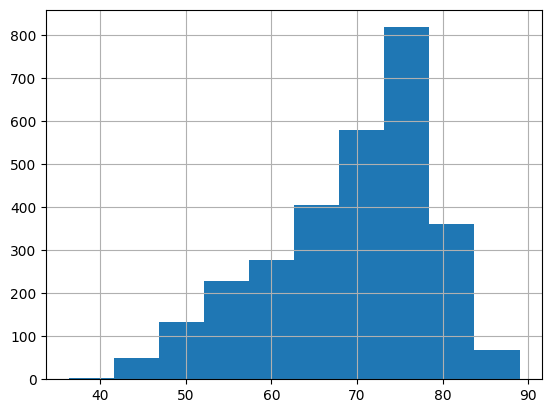

In [18]:
# Plot do histograma da variável alvo (variável quantitativa)
df['life_expectancy'].hist()

<Axes: >

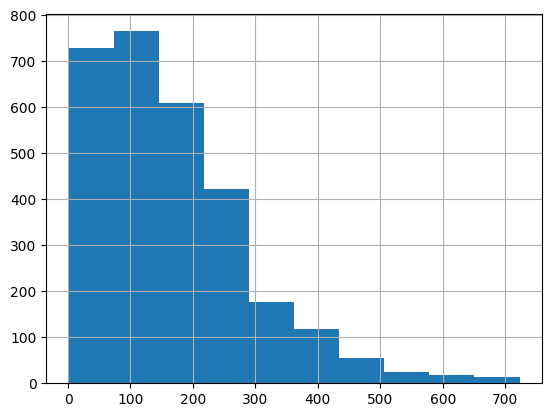

In [19]:
df['adult_mortality'].hist()

<Axes: >

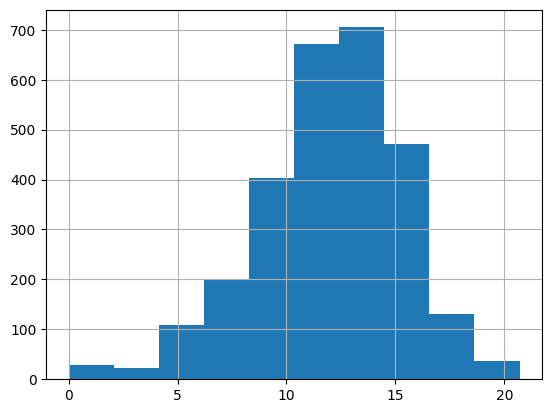

In [20]:
df['school'].hist()

In [21]:
# Visualizando o total de linhas por coluna
df.count()

country              2938
life_expectancy      2928
year                 2938
status               2938
adult_mortality      2928
inf_death            2938
alcohol              2744
hepatitisB           2385
measles              2938
bmi                  2904
polio                2919
diphtheria           2919
hiv                  2938
gdp                  2490
total_expenditure    2712
thinness_till19      2904
thinness_till9       2904
school               2775
population           2286
dtype: int64

In [22]:
# Verificando valores ausentes
missing_values = df.isnull().sum().sort_values(ascending = False)
missing_values

population           652
hepatitisB           553
gdp                  448
total_expenditure    226
alcohol              194
school               163
bmi                   34
thinness_till19       34
thinness_till9        34
diphtheria            19
polio                 19
life_expectancy       10
adult_mortality       10
year                   0
country                0
measles                0
inf_death              0
status                 0
hiv                    0
dtype: int64

In [23]:
# Checando percentual de valores missing
missing_values = missing_values[missing_values > 0] / df.shape[0] 
print(f'{missing_values * 100} %')

population           22.191967
hepatitisB           18.822328
gdp                  15.248468
total_expenditure     7.692308
alcohol               6.603131
school                5.547992
bmi                   1.157250
thinness_till19       1.157250
thinness_till9        1.157250
diphtheria            0.646698
polio                 0.646698
life_expectancy       0.340368
adult_mortality       0.340368
dtype: float64 %


## Data Munging

Normalmente quando temos 50% ou mais de valores ausentes apenas deletamos a variável. Menos de 50% idealmente aplicamos alguma estratégia de limpeza. Antes de decidir como tratar valores missing, vamos checar os outliers, pois assim podemos resolver dois problemas com uma única solução.

In [24]:
# Função para o plot da relação da variável alvo com alguns atributos
def get_pairs(data, alvo, atributos, n):
    
    # Grupos de linhas com 3 (n) gráficos por linha
    row_groups = [atributos[i:i+n] for i in range(0, len(atributos), n)]

    # Loop pelos grupos de linhas para criar cada pair plot
    for ind in row_groups:
        plot = sns.pairplot(x_vars = ind, y_vars = alvo, data = data, kind = "reg", height = 3)

    return

In [25]:
# Variável alvo
alvo = ['life_expectancy']

In [26]:
# Atributos com mais de 5% de valores missing
atributos = ['population', 'hepatitisB', 'gdp', 'total_expenditure', 'alcohol', 'school'] 

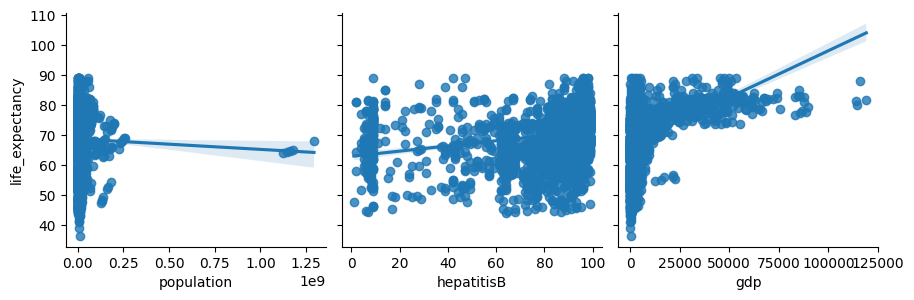

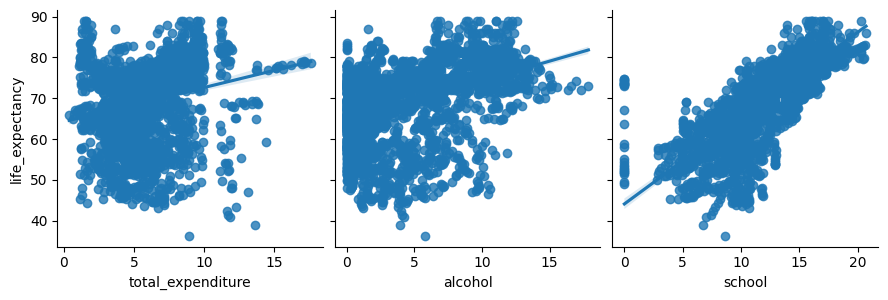

In [27]:
# Verificando outliers
get_pairs(df, alvo, atributos, 3)

In [28]:
# Valor máximo da população
df.population.max()

np.float64(1293859294.0)

In [29]:
# Checando os outliers
df[df.population > 1000000000].head()

,country,life_expectancy,year,status,adult_mortality,inf_death,alcohol,hepatitisB,measles,bmi,polio,diphtheria,hiv,gdp,total_expenditure,thinness_till19,thinness_till9,school,population
1187,India,68.0,2014,Developing,184.0,957,3.07,79.0,79563,18.1,84.0,85.0,0.2,1573.118890,4.69,26.8,27.4,11.6,1.293859e+09
1194,India,65.2,2007,Developing,26.0,1400,1.59,6.0,41144,14.4,67.0,64.0,0.3,118.166373,4.23,27.1,28.0,9.9,1.179681e+09
1195,India,64.8,2006,Developing,28.0,1500,1.37,6.0,64185,13.9,66.0,65.0,0.3,792.259698,4.25,27.1,28.0,9.7,1.161978e+09
1196,India,64.4,2005,Developing,211.0,1500,1.27,8.0,36711,13.5,65.0,65.0,0.3,77.819000,4.28,27.2,28.1,9.4,1.144119e+09
1197,India,64.0,2004,Developing,214.0,1600,1.20,6.0,55443,13.0,58.0,63.0,0.3,621.318377,4.22,27.2,28.2,9.2,1.126136e+09


In [30]:
# Removemos os outliers da variável population mantendo somente os registros que nos interessam
novo_df = df[df.population < 1000000000] 

In [31]:
# Vamos manter somente registros com school > 0
novo_df = novo_df[novo_df.school > 0] 

In [32]:
novo_df.shape

(2261, 19)

In [33]:
# Valor máximo da população
novo_df.population.max()

np.float64(258162113.0)

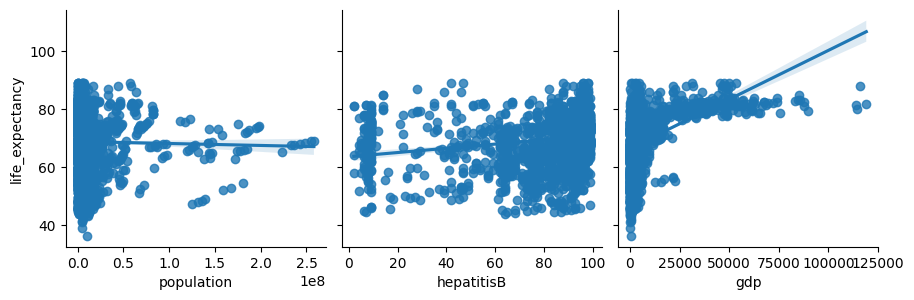

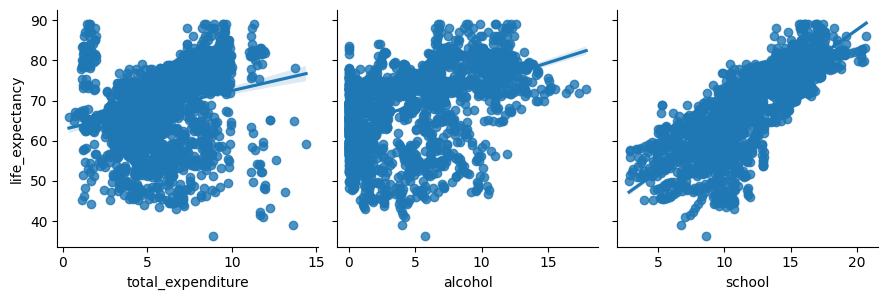

In [34]:
# Verificando outliers
get_pairs(novo_df, alvo, atributos, 3)

In [35]:
# Checando percentual de valores missing
missing_values = missing_values[missing_values > 0] / novo_df.shape[0] 
print(f'{missing_values * 100} %')

population           0.009815
hepatitisB           0.008325
gdp                  0.006744
total_expenditure    0.003402
alcohol              0.002920
school               0.002454
bmi                  0.000512
thinness_till19      0.000512
thinness_till9       0.000512
diphtheria           0.000286
polio                0.000286
life_expectancy      0.000151
adult_mortality      0.000151
dtype: float64 %


In [36]:
# Verificando valores ausentes
missing_values = novo_df.isnull().sum().sort_values(ascending = False)
missing_values

hepatitisB           463
alcohol              145
total_expenditure    144
thinness_till19       21
thinness_till9        21
bmi                   21
gdp                   14
diphtheria             3
polio                  3
life_expectancy        1
adult_mortality        1
year                   0
country                0
status                 0
inf_death              0
measles                0
hiv                    0
school                 0
population             0
dtype: int64

In [37]:
novo_df.describe()

,life_expectancy,year,adult_mortality,inf_death,alcohol,hepatitisB,measles,bmi,polio,diphtheria,hiv,gdp,total_expenditure,thinness_till19,thinness_till9,school,population
count,2260.000000,2261.000000,2260.000000,2261.000000,2116.000000,1798.000000,2261.000000,2240.000000,2258.000000,2258.000000,2261.000000,2247.000000,2117.000000,2240.000000,2240.000000,2261.000000,2.261000e+03
mean,68.773540,2007.528527,169.313274,31.237948,4.709234,79.320912,2454.226006,37.513929,81.228078,81.324624,2.058691,6670.640242,6.007643,4.833214,4.891830,11.970057,1.026072e+07
std,9.802588,4.602972,128.744704,115.487535,4.052941,25.373491,11315.971518,19.891633,23.984650,24.003757,5.674118,13578.657516,2.369427,4.556551,4.648014,3.274494,2.698889e+07
min,36.300000,2000.000000,1.000000,0.000000,0.010000,2.000000,0.000000,1.400000,3.000000,2.000000,0.100000,1.681350,0.370000,0.100000,0.100000,2.800000,3.400000e+01
25%,62.300000,2004.000000,72.000000,0.000000,0.950000,74.000000,0.000000,18.800000,75.000000,77.000000,0.100000,436.688545,4.380000,1.500000,1.500000,10.000000,1.967270e+05
50%,71.400000,2008.000000,146.000000,3.000000,4.080000,89.000000,18.000000,42.150000,92.000000,92.000000,0.100000,1526.877460,5.880000,2.900000,3.100000,12.200000,1.395398e+06
75%,75.400000,2012.000000,235.000000,23.000000,7.560000,96.000000,441.000000,55.800000,96.000000,96.000000,1.100000,5210.142342,7.700000,7.300000,7.400000,14.300000,7.395599e+06
max,89.000000,2015.000000,723.000000,1800.000000,17.870000,99.000000,212183.000000,83.300000,99.000000,99.000000,50.600000,119172.741800,14.390000,27.700000,28.600000,20.700000,2.581621e+08


In [38]:
# Função para o Replace das linhas vazias com a mediana
def impute_median(dados):
    return dados.fillna(dados.median())

In [39]:
# Removendo valores missing (observe as diferentes formas de notação do lado esquerdo do sinal de igual)
novo_df.loc[:,'population'] = novo_df['population'].transform(impute_median)
novo_df.hepatitisB = novo_df['hepatitisB'].transform(impute_median)
novo_df.alcohol = novo_df['alcohol'].transform(impute_median)
novo_df.total_expenditure = novo_df['total_expenditure'].transform(impute_median)

In [40]:
# Checando percentual de valores missing
missing_values = missing_values[missing_values > 0] / novo_df.shape[0] 
print(f'{missing_values * 100} %')

hepatitisB           20.477665
alcohol               6.413092
total_expenditure     6.368863
thinness_till19       0.928793
thinness_till9        0.928793
bmi                   0.928793
gdp                   0.619195
diphtheria            0.132685
polio                 0.132685
life_expectancy       0.044228
adult_mortality       0.044228
dtype: float64 %


In [41]:
# Remove registros com valores nulos
novo_df.dropna(inplace = True)

In [42]:
# Verifique se há valores ausentes
missing_values = novo_df.isnull().sum().sort_values(ascending = False)
missing_values

country              0
life_expectancy      0
year                 0
status               0
adult_mortality      0
inf_death            0
alcohol              0
hepatitisB           0
measles              0
bmi                  0
polio                0
diphtheria           0
hiv                  0
gdp                  0
total_expenditure    0
thinness_till19      0
thinness_till9       0
school               0
population           0
dtype: int64

In [43]:
# Shape
novo_df.shape

(2222, 19)

## Engenharia de Recursos (Feature Engineering)

> Como há diferença muito grande de população entre os países usar essa variável pode ser arriscado. Vamos criar uma nova variável e categorizar os países em uma de 3 faixas possíveis de população.

In [44]:
# Criamos os pontos de corte (cutoffs) para dividir a população em 3 categorias
IQR = [novo_df.population.quantile(0.33), novo_df.population.quantile(0.67)]

In [45]:
IQR

[np.float64(442857.6900000001), np.float64(4299567.140000006)]

In [46]:
# Cria um novo recurso dividindo a população em 3 tamanhos
novo_df['pop_size'] = 1
novo_df.loc[(novo_df.population < IQR[1]) & (novo_df.population > IQR[0]), 'pop_size'] = 2
novo_df.loc[novo_df.population >= IQR[1], 'pop_size'] = 3

In [47]:
# Dataset
novo_df.head()

,country,life_expectancy,year,status,adult_mortality,inf_death,alcohol,hepatitisB,measles,bmi,polio,diphtheria,hiv,gdp,total_expenditure,thinness_till19,thinness_till9,school,population,pop_size
0,Afghanistan,65.0,2015,Developing,263.0,62,0.01,65.0,1154,19.1,6.0,65.0,0.1,584.259210,8.16,17.2,17.3,10.1,33736494.0,3
1,Afghanistan,59.9,2014,Developing,271.0,64,0.01,62.0,492,18.6,58.0,62.0,0.1,612.696514,8.18,17.5,17.5,10.0,327582.0,1
2,Afghanistan,59.9,2013,Developing,268.0,66,0.01,64.0,430,18.1,62.0,64.0,0.1,631.744976,8.13,17.7,17.7,9.9,31731688.0,3
3,Afghanistan,59.5,2012,Developing,272.0,69,0.01,67.0,2787,17.6,67.0,67.0,0.1,669.959000,8.52,17.9,18.0,9.8,3696958.0,2
4,Afghanistan,59.2,2011,Developing,275.0,71,0.01,68.0,3013,17.2,68.0,68.0,0.1,63.537231,7.87,18.2,18.2,9.5,2978599.0,2


> As variáveis alcohol e bmi têm uma relação direta e natural. Vamos criar uma nova variável chamada life_style com a combinação dessas duas variáveis.

In [48]:
# Criando a nova variável
novo_df['lifestyle'] = 0
novo_df.lifestyle = novo_df['bmi'] * novo_df['alcohol']

In [49]:
novo_df.head()

,country,life_expectancy,year,status,adult_mortality,inf_death,alcohol,hepatitisB,measles,bmi,...,diphtheria,hiv,gdp,total_expenditure,thinness_till19,thinness_till9,school,population,pop_size,lifestyle
0,Afghanistan,65.0,2015,Developing,263.0,62,0.01,65.0,1154,19.1,...,65.0,0.1,584.259210,8.16,17.2,17.3,10.1,33736494.0,3,0.191
1,Afghanistan,59.9,2014,Developing,271.0,64,0.01,62.0,492,18.6,...,62.0,0.1,612.696514,8.18,17.5,17.5,10.0,327582.0,1,0.186
2,Afghanistan,59.9,2013,Developing,268.0,66,0.01,64.0,430,18.1,...,64.0,0.1,631.744976,8.13,17.7,17.7,9.9,31731688.0,3,0.181
3,Afghanistan,59.5,2012,Developing,272.0,69,0.01,67.0,2787,17.6,...,67.0,0.1,669.959000,8.52,17.9,18.0,9.8,3696958.0,2,0.176
4,Afghanistan,59.2,2011,Developing,275.0,71,0.01,68.0,3013,17.2,...,68.0,0.1,63.537231,7.87,18.2,18.2,9.5,2978599.0,2,0.172


In [50]:
# Verifique se há valores ausentes
missing_values = novo_df.isnull().sum().sort_values(ascending = False)
missing_values

country              0
life_expectancy      0
year                 0
status               0
adult_mortality      0
inf_death            0
alcohol              0
hepatitisB           0
measles              0
bmi                  0
polio                0
diphtheria           0
hiv                  0
gdp                  0
total_expenditure    0
thinness_till19      0
thinness_till9       0
school               0
population           0
pop_size             0
lifestyle            0
dtype: int64

In [51]:
novo_df.dtypes

country               object
life_expectancy      float64
year                   int64
status                object
adult_mortality      float64
inf_death              int64
alcohol              float64
hepatitisB           float64
measles                int64
bmi                  float64
polio                float64
diphtheria           float64
hiv                  float64
gdp                  float64
total_expenditure    float64
thinness_till19      float64
thinness_till9       float64
school               float64
population           float64
pop_size               int64
lifestyle            float64
dtype: object

In [52]:
novo_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2222 entries, 0 to 2937
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   country            2222 non-null   object 
 1   life_expectancy    2222 non-null   float64
 2   year               2222 non-null   int64  
 3   status             2222 non-null   object 
 4   adult_mortality    2222 non-null   float64
 5   inf_death          2222 non-null   int64  
 6   alcohol            2222 non-null   float64
 7   hepatitisB         2222 non-null   float64
 8   measles            2222 non-null   int64  
 9   bmi                2222 non-null   float64
 10  polio              2222 non-null   float64
 11  diphtheria         2222 non-null   float64
 12  hiv                2222 non-null   float64
 13  gdp                2222 non-null   float64
 14  total_expenditure  2222 non-null   float64
 15  thinness_till19    2222 non-null   float64
 16  thinness_till9     2222 non-n

## Análise de Correlação Para Verificar Multicolinearidade

Queremos que as variáveis preditoras tenham uma alta correlação com a variável alvo, mas não queremos que as variáveis preditoras tenham alta correlação entre si. Se houver alta correlação entre as variáveis preditoras isso é chamado de multicolinearidade e fere uma das suposições da regressão.

A correlação é uma medida da relação entre as variáveis. O coeficiente de correlação é um valor de -1 a +1, sendo:

**-1 indica alta correlação negativa.**

**+1 indica ata correlação positiva.**

**0 indica que não há correlação.**

Correlação não implica causalidade. Por exemplo: Sempre que aumenta o consumo de sorvete aumenta a presença de tubarões na praia. Provavelmente ambos os eventos ocorrem no verão e estão correlacionados, mas isso não significa que um evento causa o outro. Para afirma isso teríamos que fazer uma análise de causalidade.

In [53]:
# Correlação das variáveis numéricas no conjunto de dados
novo_df.corr(numeric_only=True)

,life_expectancy,year,adult_mortality,inf_death,alcohol,hepatitisB,measles,bmi,polio,diphtheria,hiv,gdp,total_expenditure,thinness_till19,thinness_till9,school,population,pop_size,lifestyle
life_expectancy,1.000000,0.176117,-0.675711,-0.188937,0.417684,0.145320,-0.138672,0.591826,0.439880,0.461301,-0.570218,0.464855,0.223801,-0.494762,-0.487918,0.787895,-0.018328,-0.072341,0.524638
year,0.176117,1.000000,-0.074519,-0.042089,-0.070014,0.025485,-0.104324,0.095873,0.089729,0.138480,-0.153504,0.089318,0.058259,-0.052084,-0.056654,0.203825,0.040187,0.033903,-0.028838
adult_mortality,-0.675711,-0.074519,1.000000,0.068450,-0.212432,-0.090739,0.002966,-0.379885,-0.232471,-0.230656,0.537801,-0.284487,-0.121580,0.313513,0.320073,-0.448258,-0.002467,0.091056,-0.297620
inf_death,-0.188937,-0.042089,0.068450,1.000000,-0.111326,-0.122679,0.492842,-0.232869,-0.168426,-0.172427,0.017758,-0.107413,-0.151023,0.445476,0.450111,-0.227441,0.332226,0.161808,-0.160287
alcohol,0.417684,-0.070014,-0.212432,-0.111326,1.000000,0.105768,-0.031832,0.384038,0.245070,0.250085,-0.055847,0.444414,0.258454,-0.416774,-0.406877,0.598579,-0.007516,0.012318,0.873168
hepatitisB,0.145320,0.025485,-0.090739,-0.122679,0.105768,1.000000,-0.053466,0.105644,0.363550,0.457382,-0.080330,0.058189,0.097827,-0.076983,-0.081630,0.151423,-0.052076,-0.037878,0.116639
measles,-0.138672,-0.104324,0.002966,0.492842,-0.031832,-0.053466,1.000000,-0.164890,-0.113775,-0.118252,0.026085,-0.068761,-0.105133,0.198874,0.193109,-0.153803,0.166975,0.056582,-0.101495
bmi,0.591826,0.095873,-0.379885,-0.232869,0.384038,0.105644,-0.164890,1.000000,0.277083,0.279748,-0.244071,0.307833,0.232984,-0.561643,-0.569161,0.604893,-0.053069,-0.045490,0.670402
polio,0.439880,0.089729,-0.232471,-0.168426,0.245070,0.363550,-0.113775,0.277083,1.000000,0.675514,-0.150137,0.196704,0.166099,-0.223685,-0.225501,0.435264,-0.037620,-0.034486,0.282803
diphtheria,0.461301,0.138480,-0.230656,-0.172427,0.250085,0.457382,-0.118252,0.279748,0.675514,1.000000,-0.160103,0.193807,0.177380,-0.239140,-0.233628,0.452468,-0.015831,-0.023491,0.288499


Observe a primeira linha da tabela com a correlação de cada variável com a variável alvo (life_expectancy). Buscamos pelas maiores correlações (positivas ou negativas). Vamos considerar 0.30 como nossa marca de corte. Para facilitar a nossa vida vamos filtrar a tabela de correlação.

In [54]:
# Filtrando a matriz de correlação
dfCorr = novo_df.corr(numeric_only=True)
df_filtro_1 = dfCorr[((dfCorr >= .3) | (dfCorr <= -.3)) & (dfCorr !=1.000)]
df_filtro_1

,life_expectancy,year,adult_mortality,inf_death,alcohol,hepatitisB,measles,bmi,polio,diphtheria,hiv,gdp,total_expenditure,thinness_till19,thinness_till9,school,population,pop_size,lifestyle
life_expectancy,NaN,NaN,-0.675711,NaN,0.417684,NaN,NaN,0.591826,0.439880,0.461301,-0.570218,0.464855,NaN,-0.494762,-0.487918,0.787895,NaN,NaN,0.524638
year,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
adult_mortality,-0.675711,NaN,NaN,NaN,NaN,NaN,NaN,-0.379885,NaN,NaN,0.537801,NaN,NaN,0.313513,0.320073,-0.448258,NaN,NaN,NaN
inf_death,NaN,NaN,NaN,NaN,NaN,NaN,0.492842,NaN,NaN,NaN,NaN,NaN,NaN,0.445476,0.450111,NaN,0.332226,NaN,NaN
alcohol,0.417684,NaN,NaN,NaN,NaN,NaN,NaN,0.384038,NaN,NaN,NaN,0.444414,NaN,-0.416774,-0.406877,0.598579,NaN,NaN,0.873168
hepatitisB,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.363550,0.457382,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
measles,NaN,NaN,NaN,0.492842,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bmi,0.591826,NaN,-0.379885,NaN,0.384038,NaN,NaN,NaN,NaN,NaN,NaN,0.307833,NaN,-0.561643,-0.569161,0.604893,NaN,NaN,0.670402
polio,0.439880,NaN,NaN,NaN,NaN,0.363550,NaN,NaN,NaN,0.675514,NaN,NaN,NaN,NaN,NaN,0.435264,NaN,NaN,NaN
diphtheria,0.461301,NaN,NaN,NaN,NaN,0.457382,NaN,NaN,0.675514,NaN,NaN,NaN,NaN,NaN,NaN,0.452468,NaN,NaN,NaN


As variáveis adult_mortality, alcohol, bmi, polio, diphtheria, hiv, gdp, thinness_till19, thinness_till9, school e lifestyle atendem ao nosso critério.

Agora devemos checar uma das suposições da Regressão Linear e identificar possíveis problemas de multicolinearidade (alta correlação entre as variáveis preditoras). Com base nesse critério eliminamos uma de duas variáveis preditoras altamente correlacionadas. Vamos considerar 0.65 como marca de corte. Vamos filtrar mais uma vez a matriz de correlação.

In [55]:
# Filtrando a matriz de correlação
dfCorr = novo_df.corr(numeric_only=True)
df_filtro_2 = dfCorr[((dfCorr >= .65) | (dfCorr <= -.65)) & (dfCorr !=1.000)]
df_filtro_2 = df_filtro_2.drop('life_expectancy', axis=1)
df_filtro_2 = df_filtro_2.drop('life_expectancy', axis=0)
df_filtro_2

,year,adult_mortality,inf_death,alcohol,hepatitisB,measles,bmi,polio,diphtheria,hiv,gdp,total_expenditure,thinness_till19,thinness_till9,school,population,pop_size,lifestyle
year,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
adult_mortality,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
inf_death,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
alcohol,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.873168
hepatitisB,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
measles,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bmi,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.670402
polio,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.675514,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
diphtheria,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.675514,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
hiv,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


As variáveis adult_mortality, diphtheria, hiv, gdp, thinness_till19, school e lifestyle atendem ao nosso critério. Vamos criar o dataset final com essas variáveis.

Se preferir visualizar as correlações de forma gráfica, aqui está um exemplo de Pair Plot.

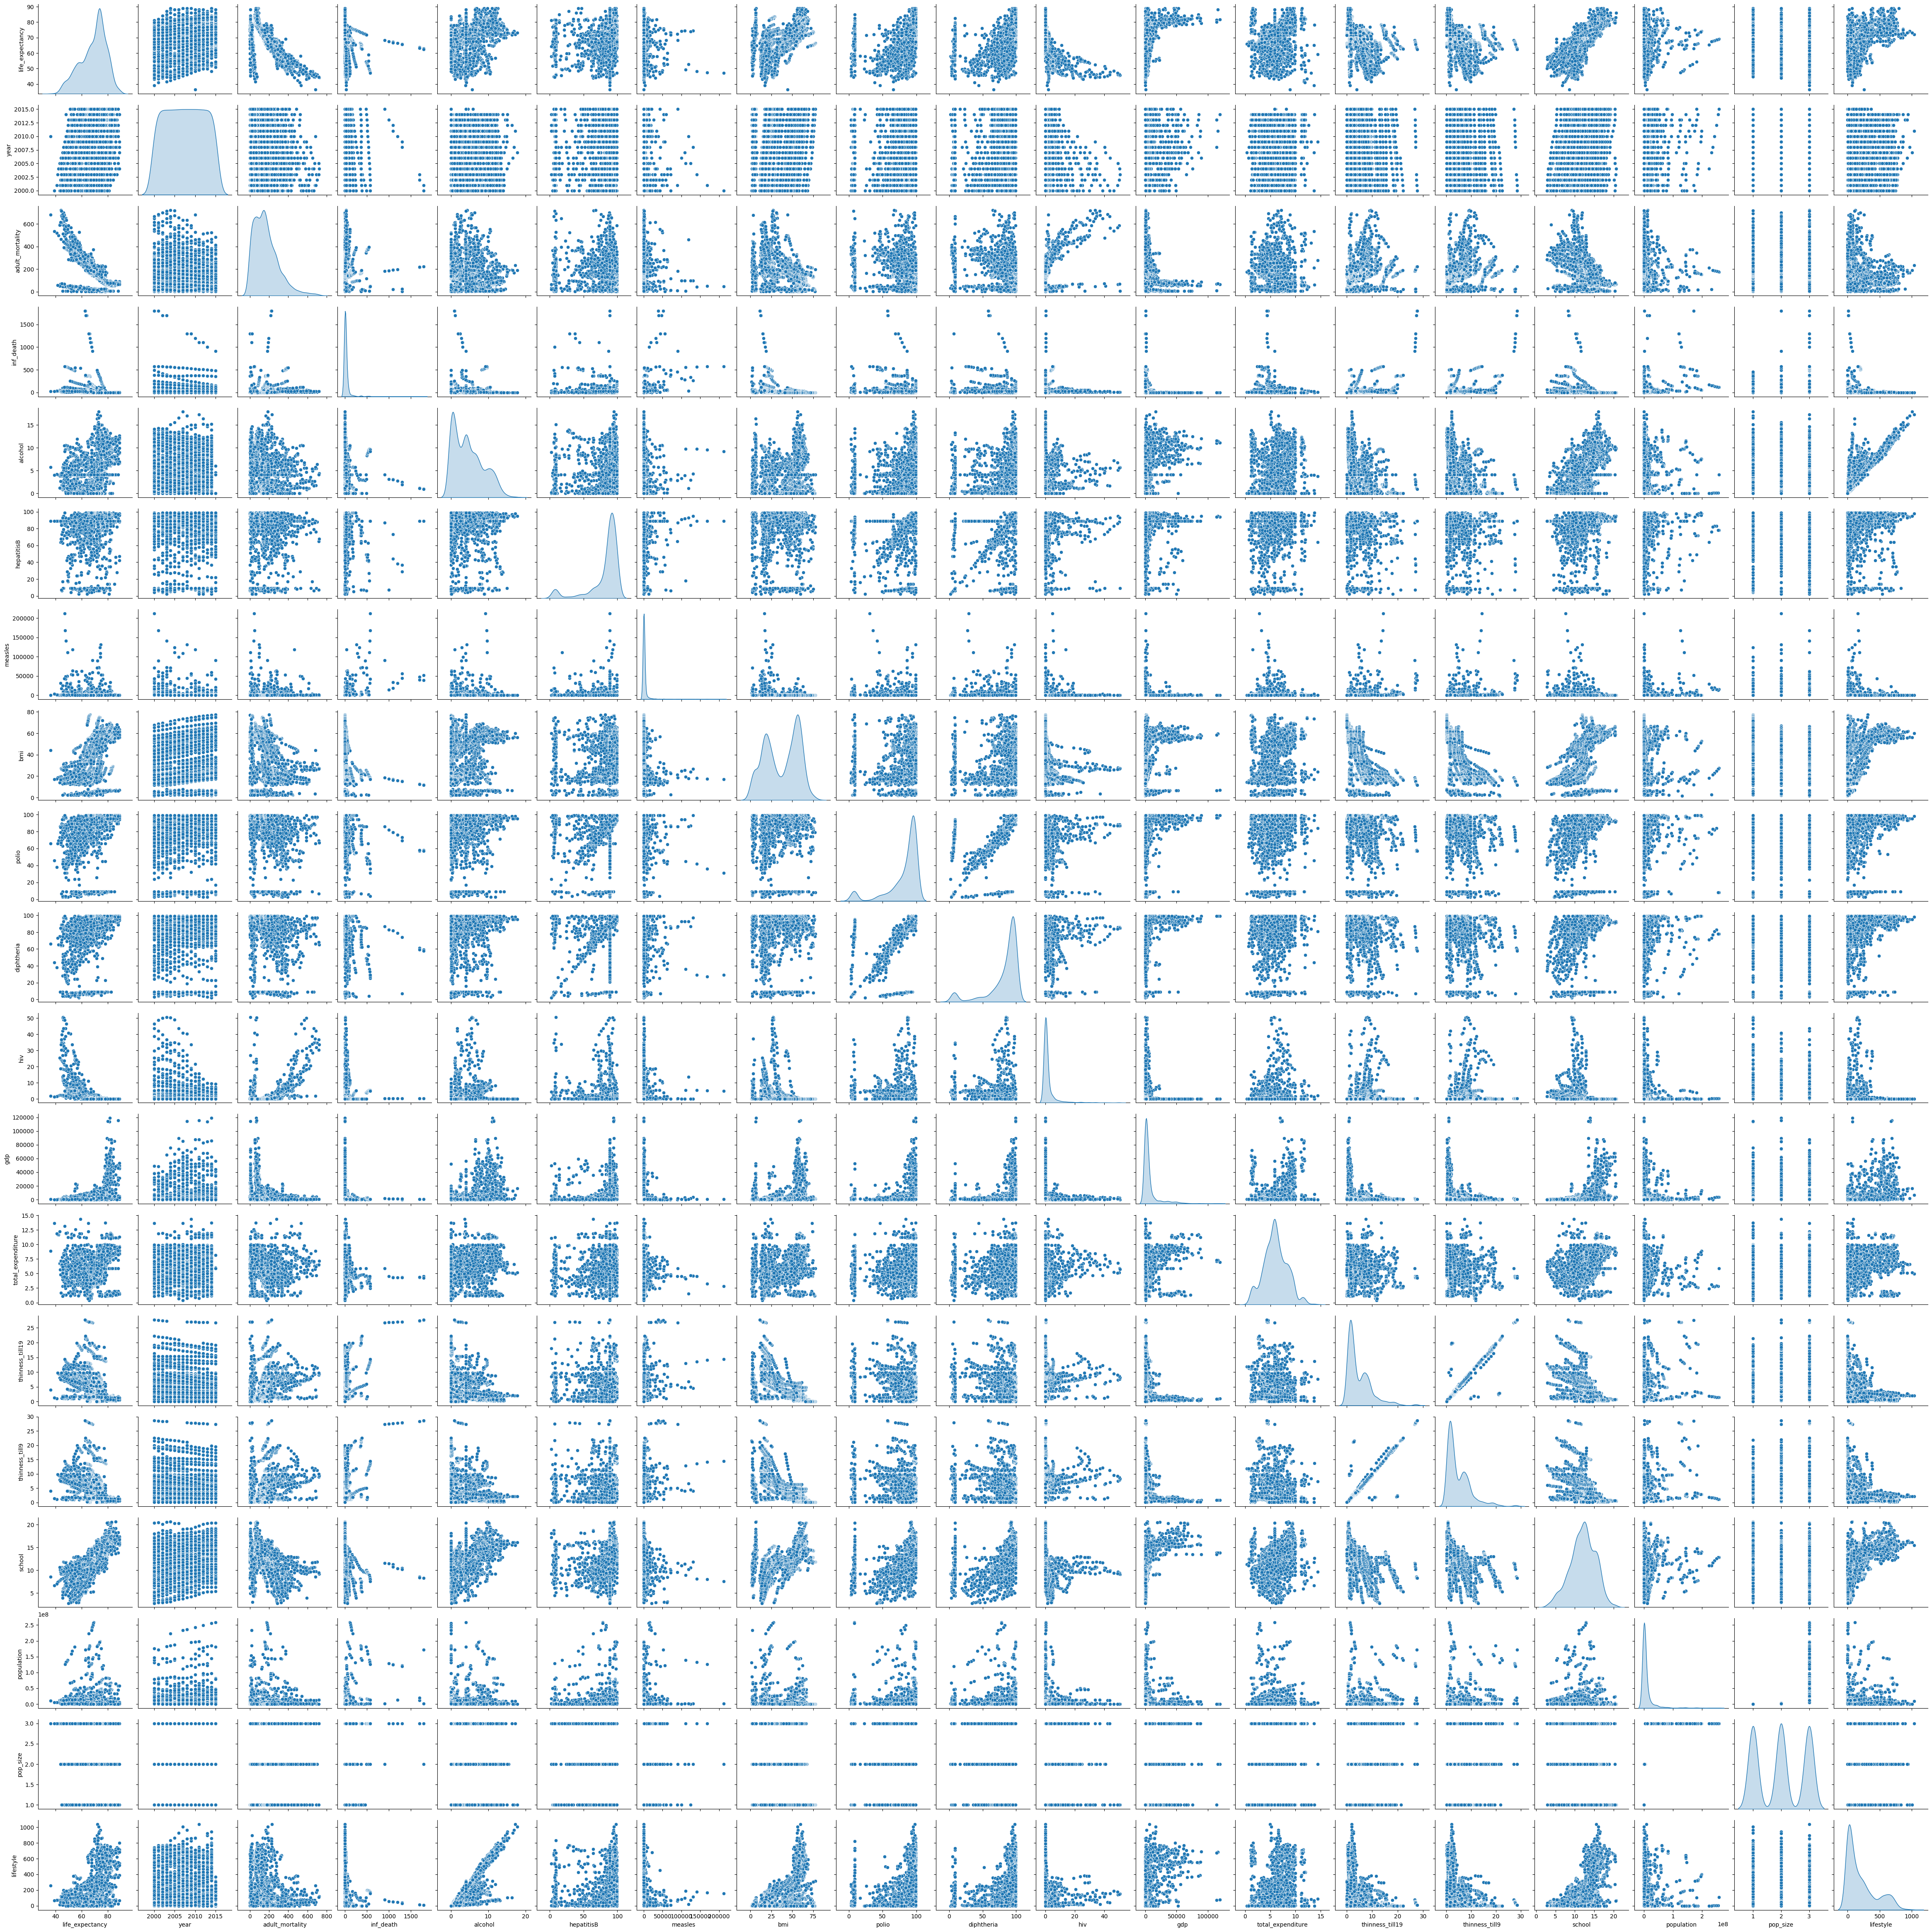

In [56]:
# Checando a correlação entre as variáveis
sns.pairplot(novo_df, diag_kind = "kde", height = 2.5)

> As variáveis adult_mortality, diphtheria, hiv, gdp, thinness_till19, school e lifestyle atendem ao nosso critério.

In [57]:
# Preparando o novo dataset
novo_df_final = pd.DataFrame({'life_expectancy': novo_df['life_expectancy'],
                              'adult_mortality': novo_df['adult_mortality'],
                              'diphtheria': novo_df['diphtheria'],
                              'hiv': novo_df['hiv'],
                              'gdp': novo_df['gdp'],
                              'thinness_till19': novo_df['thinness_till19'],
                              'school': novo_df['school'],
                              'lifestyle': novo_df['lifestyle'],})

In [58]:
novo_df_final.head()

,life_expectancy,adult_mortality,diphtheria,hiv,gdp,thinness_till19,school,lifestyle
0,65.0,263.0,65.0,0.1,584.259210,17.2,10.1,0.191
1,59.9,271.0,62.0,0.1,612.696514,17.5,10.0,0.186
2,59.9,268.0,64.0,0.1,631.744976,17.7,9.9,0.181
3,59.5,272.0,67.0,0.1,669.959000,17.9,9.8,0.176
4,59.2,275.0,68.0,0.1,63.537231,18.2,9.5,0.172


In [59]:
# Verifique se há valores ausentes
missing_values = novo_df_final.isnull().sum().sort_values(ascending = False)
missing_values

life_expectancy    0
adult_mortality    0
diphtheria         0
hiv                0
gdp                0
thinness_till19    0
school             0
lifestyle          0
dtype: int64

In [60]:
# Visualizando o total de linhas por coluna
novo_df_final.count()

life_expectancy    2222
adult_mortality    2222
diphtheria         2222
hiv                2222
gdp                2222
thinness_till19    2222
school             2222
lifestyle          2222
dtype: int64

In [61]:
# Checando multicolinearidade e removendo varáveis altamente correlacionadas
corr_map = novo_df_final.corr()
corr_map

,life_expectancy,adult_mortality,diphtheria,hiv,gdp,thinness_till19,school,lifestyle
life_expectancy,1.000000,-0.675711,0.461301,-0.570218,0.464855,-0.494762,0.787895,0.524638
adult_mortality,-0.675711,1.000000,-0.230656,0.537801,-0.284487,0.313513,-0.448258,-0.297620
diphtheria,0.461301,-0.230656,1.000000,-0.160103,0.193807,-0.239140,0.452468,0.288499
hiv,-0.570218,0.537801,-0.160103,1.000000,-0.131684,0.212936,-0.239688,-0.155901
gdp,0.464855,-0.284487,0.193807,-0.131684,1.000000,-0.311480,0.494044,0.466371
thinness_till19,-0.494762,0.313513,-0.239140,0.212936,-0.311480,1.000000,-0.516931,-0.473522
school,0.787895,-0.448258,0.452468,-0.239688,0.494044,-0.516931,1.000000,0.645893
lifestyle,0.524638,-0.297620,0.288499,-0.155901,0.466371,-0.473522,0.645893,1.000000


In [62]:
# Função para o plot da matriz de correlação
def CorrMat(df, dropDuplicates = True, xrot = 70, yrot = 0, label = 'Variable'):

    # Excluir correlações duplicadas mascarando os valores superiores à direita
    if dropDuplicates:
        mask = np.zeros_like(df, dtype = np.bool)
        mask[np.triu_indices_from(mask)] = True

    # Definir cor do plano de fundo / estilo do gráfico
    sns.set_style(style = 'dark')
    fig, ax = plt.subplots(figsize = (14, 12))

    # Adiciona mapa de cores do vermelho ao azul
    plt.title("Matriz de Correlação")

    # Desenha gráfico de correlação com ou sem duplicatas
    if dropDuplicates:
        sns.heatmap(df, mask = mask, square = True, linewidth = .5, cbar_kws = {"shrink": .5}, ax = ax)
        plt.xlabel(label)
        plt.ylabel(label)
        plt.xticks(rotation=xrot)
        plt.yticks(rotation=yrot)

    else:
        sns.heatmap(df, square = True, linewidth = .5, cbar_kws = {"shrink": .5}, ax = ax)
        plt.xlabel(label)
        plt.ylabel(label)
        plt.xticks(rotation = xrot)
        plt.yticks(rotation = yrot)
    return

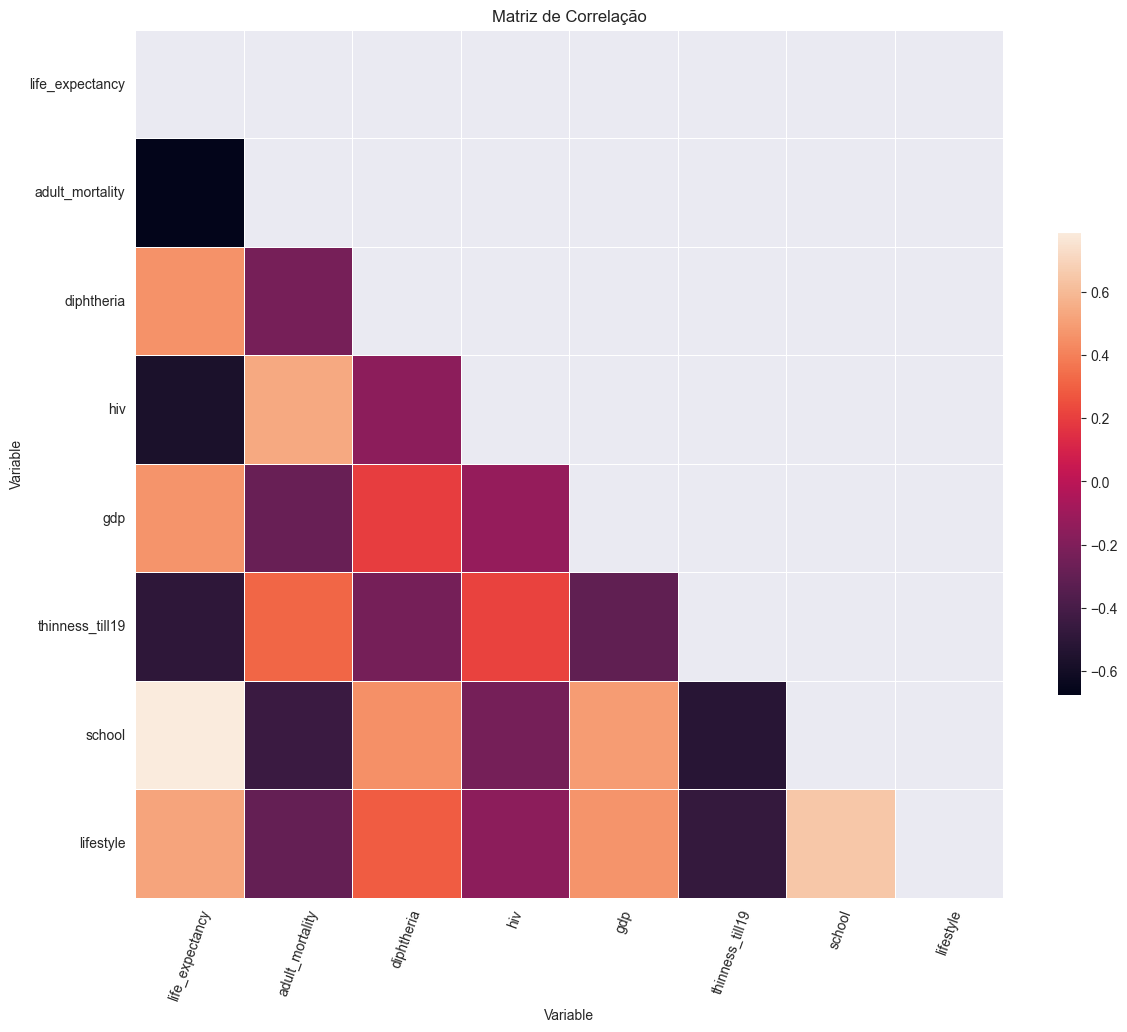

In [63]:
# Plot da matriz de correlação
CorrMat(corr_map)

In [64]:
# Dataset
novo_df_final.head()

,life_expectancy,adult_mortality,diphtheria,hiv,gdp,thinness_till19,school,lifestyle
0,65.0,263.0,65.0,0.1,584.259210,17.2,10.1,0.191
1,59.9,271.0,62.0,0.1,612.696514,17.5,10.0,0.186
2,59.9,268.0,64.0,0.1,631.744976,17.7,9.9,0.181
3,59.5,272.0,67.0,0.1,669.959000,17.9,9.8,0.176
4,59.2,275.0,68.0,0.1,63.537231,18.2,9.5,0.172


In [65]:
# Dataset
novo_df_final.dtypes

life_expectancy    float64
adult_mortality    float64
diphtheria         float64
hiv                float64
gdp                float64
thinness_till19    float64
school             float64
lifestyle          float64
dtype: object

In [66]:
novo_df_final.shape

(2222, 8)

### Modelagem Estatística

In [67]:
# Primeira versão do modelo de regressão
formula = 'life_expectancy ~ adult_mortality + diphtheria + ' \
'hiv + gdp + thinness_till19 + school + lifestyle'
modelo_v1 = ols(formula, data = novo_df_final).fit()
modelo_v1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:        life_expectancy   R-squared:                       0.827
Model:                            OLS   Adj. R-squared:                  0.826
Method:                 Least Squares   F-statistic:                     1512.
Date:                Tue, 09 Jun 2026   Prob (F-statistic):               0.00
Time:                        18:54:33   Log-Likelihood:                -6283.5
No. Observations:                2222   AIC:                         1.258e+04
Df Residuals:                    2214   BIC:                         1.263e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          51.0797      0.566     90.285      0.000      49.970      52.189
adult_mortality    -0.0179      0.001    -20.496      0.000      -0.020      -0.016
diphtheria          0.0444      0.004     10.819      0.000       0.036       0.053
hiv                -0.4911      0.018    -27.123      0.000      -0.527      -0.456
gdp              5.578e-05   7.56e-06      7.383      0.000     4.1e-05    7.06e-05
thinness_till19    -0.1150      0.023     -5.012      0.000      -0.160      -0.070
school              1.5319      0.042     36.282      0.000       1.449       1.615
lifestyle          -0.0004      0.001     -0.695      0.487      -0.001       0.001
==============================================================================
Omnibus:                      125.254   Durbin-Watson:                   0.585
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              223.628
Skew:                          -0.424   Prob(JB):                     2.75e-49
Kurtosis:                       4.302   Cond. No.                     9.91e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 9.91e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

> A variiável lifestyle apresenta um valor-p superior a 0.05 e, portanto, não é significativamente estatística para prever a variável alvo. Vamos removê-la.

In [68]:
# Segunda versão do modelo de regressão
formula = 'life_expectancy ~ adult_mortality + diphtheria + hiv + gdp + thinness_till19 + school'
modelo_v2 = ols(formula, data = novo_df_final).fit()
modelo_v2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:        life_expectancy   R-squared:                       0.827
Model:                            OLS   Adj. R-squared:                  0.826
Method:                 Least Squares   F-statistic:                     1764.
Date:                Tue, 09 Jun 2026   Prob (F-statistic):               0.00
Time:                        18:54:33   Log-Likelihood:                -6283.7
No. Observations:                2222   AIC:                         1.258e+04
Df Residuals:                    2215   BIC:                         1.262e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          51.1441      0.558     91.649      0.000      50.050      52.238
adult_mortality    -0.0179      0.001    -20.514      0.000      -0.020      -0.016
diphtheria          0.0444      0.004     10.819      0.000       0.036       0.052
hiv                -0.4913      0.018    -27.137      0.000      -0.527      -0.456
gdp              5.467e-05   7.38e-06      7.404      0.000    4.02e-05    6.91e-05
thinness_till19    -0.1118      0.022     -4.976      0.000      -0.156      -0.068
school              1.5198      0.038     39.489      0.000       1.444       1.595
==============================================================================
Omnibus:                      126.492   Durbin-Watson:                   0.584
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              225.186
Skew:                          -0.429   Prob(JB):                     1.26e-49
Kurtosis:                       4.303   Cond. No.                     9.78e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 9.78e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

> Observe a nota 2 acima. Parace haver multicolinearidade nos preditores. Podemos voltar e rever nosso critério de decisão e remover variáveis que estejam com correlação acima de 0.55, por exemplo. Mas antes disso, vamos padronizar os dados e colocar tudo na mesma escala e avaliar o resultado.

In [69]:
# Aplicando escala aos dados
atributos = ['adult_mortality', 'diphtheria', 'hiv', 'gdp', 'thinness_till19', 'school'] 

# Escala
scaler = StandardScaler()
scaler.fit(novo_df_final[atributos])
scaled_features = scaler.transform(novo_df_final[atributos])

# Criando um dataframe com dados em escala
scaled_features_df = pd.DataFrame(scaled_features, columns = atributos, index = novo_df_final.index)
scaled_features_df.head()

,adult_mortality,diphtheria,hiv,gdp,thinness_till19,school
0,0.732306,-0.699291,-0.346871,-0.450787,2.708739,-0.596552
1,0.794280,-0.825348,-0.346871,-0.448702,2.774420,-0.627375
2,0.771040,-0.741310,-0.346871,-0.447305,2.818208,-0.658198
3,0.802027,-0.615253,-0.346871,-0.444503,2.861995,-0.689021
4,0.825268,-0.573234,-0.346871,-0.488966,2.927676,-0.781490


In [70]:
# Terceira versão do modelo
modelo_v3 = sm.OLS(endog = novo_df_final['life_expectancy'], 
                   exog = sm.add_constant(scaled_features_df.values)).fit()
modelo_v3.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:        life_expectancy   R-squared:                       0.827
Model:                            OLS   Adj. R-squared:                  0.826
Method:                 Least Squares   F-statistic:                     1764.
Date:                Tue, 09 Jun 2026   Prob (F-statistic):               0.00
Time:                        18:54:33   Log-Likelihood:                -6283.7
No. Observations:                2222   AIC:                         1.258e+04
Df Residuals:                    2215   BIC:                         1.262e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         68.8544      0.087    791.929      0.000      68.684      69.025
x1            -2.3098      0.113    -20.514      0.000      -2.531      -2.089
x2             1.0575      0.098     10.819      0.000       0.866       1.249
x3            -2.8087      0.104    -27.137      0.000      -3.012      -2.606
x4             0.7456      0.101      7.404      0.000       0.548       0.943
x5            -0.5105      0.103     -4.976      0.000      -0.712      -0.309
x6             4.9308      0.125     39.489      0.000       4.686       5.176
==============================================================================
Omnibus:                      126.492   Durbin-Watson:                   0.584
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              225.186
Skew:                          -0.429   Prob(JB):                     1.26e-49
Kurtosis:                       4.303   Cond. No.                         2.78
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

> A padronização e escala dados nos ajudou a construir um modelo melhor. Vamos agora usar modelagem preditiva e construir a versão final do nosso modelo. 

## Modelagem Preditiva

In [71]:
novo_df_final.head(2)

,life_expectancy,adult_mortality,diphtheria,hiv,gdp,thinness_till19,school,lifestyle
0,65.0,263.0,65.0,0.1,584.259210,17.2,10.1,0.191
1,59.9,271.0,62.0,0.1,612.696514,17.5,10.0,0.186


In [72]:
# Remove a coluna lifestyle
novo_df_final = novo_df_final.drop('lifestyle', axis=1)

In [73]:
novo_df_final.head(2)

,life_expectancy,adult_mortality,diphtheria,hiv,gdp,thinness_till19,school
0,65.0,263.0,65.0,0.1,584.259210,17.2,10.1
1,59.9,271.0,62.0,0.1,612.696514,17.5,10.0


In [74]:
# Split dos dados em X e Y
X = novo_df_final[['adult_mortality', 'diphtheria', 'hiv', 'gdp', 'thinness_till19', 'school']].values
y = novo_df_final.life_expectancy.values.reshape(-1,1)

In [75]:
# Split em treino e teste
x_treino, x_teste, y_treino, y_teste = train_test_split(X, y, 
                                                        test_size = 0.2, 
                                                        random_state = 0)

In [76]:
len(x_treino)

1777

In [77]:
len(y_treino)

1777

In [78]:
len(x_teste)

445

In [79]:
len(y_teste)

445

In [80]:
# Escala nos dados de treino. Fazemos o Fit somente com dados de treino!!!
scaler = StandardScaler()
scaler.fit(x_treino)

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [81]:
# Aplicamos o scaler nos dados de treino e teste
x_treino_scaled = scaler.transform(x_treino)
x_teste_scaled = scaler.transform(x_teste)

In [82]:
x_treino_scaled

array([[-0.55978641,  0.72991357, -0.35804767, -0.26743648,  0.3326693 ,
         0.0108209 ],
       [ 0.17137158,  0.06020586, -0.30499878, -0.49181556, -0.57420632,
        -0.60946091],
       [-0.28560216,  0.52062991, -0.35804767, -0.26271971, -0.61739087,
         0.07284908],
       ...,
       [-0.7654246 ,  0.56248664, -0.35804767, -0.14645712, -0.81172137,
         1.53051133],
       [ 1.12340023, -1.02806918,  0.08402642, -0.47849201,  0.91566078,
        -1.53988363],
       [-0.20182364,  0.72991357, -0.35804767, -0.0069863 , -0.53102177,
         1.06529998]], shape=(1777, 6))

In [83]:
x_treino_scaled.shape

(1777, 6)

In [84]:
x_teste_scaled.shape

(445, 6)

https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html

In [85]:
# Cria o modelo
modelo_lr_v1 = LinearRegression()

In [86]:
# Treinamento do modelo
modelo_lr_v1.fit(x_treino_scaled, y_treino)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [87]:
# O que o modelo aprendeu:
print("Coeficientes: \n", modelo_lr_v1.coef_)

Coeficientes: 
 [[-2.42143733  1.07279933 -2.77472198  0.68492599 -0.41365552  5.05196096]]


In [88]:
# Previsões com dados de treino
y_pred_treino = modelo_lr_v1.predict(x_treino_scaled)

In [89]:
# Print das métricas em treino
print('Mean Absolute Error:', metrics.mean_absolute_error(y_treino, y_pred_treino))
print('Mean Squared Error:', metrics.mean_squared_error(y_treino, y_pred_treino))
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_treino, y_pred_treino)))
print('R2 Score:', metrics.r2_score(y_treino, y_pred_treino))

Mean Absolute Error: 3.1442899659411325
Mean Squared Error: 16.798649509251447
Root Mean Squared Error: 4.098615560070431
R2 Score: 0.8305630982987356


## Avaliação do Modelo

Podemos calcular as métricas com os dados de treino como fizemos anteriormente, mas a avaliação do modelo sempre deve ser feita com dados que o modelo ainda não viu, dados de teste.

In [90]:
# Previsões com dados de teste sem padronização (errado)
y_pred_teste = modelo_lr_v1.predict(x_teste)

In [91]:
# Dataframe com as previsões e valores reais
df_previsoes = pd.DataFrame({'Valor_Real': y_teste.flatten(), 'Valor_Previsto': y_pred_teste.flatten()})
df_previsoes.head()

,Valor_Real,Valor_Previsto
0,75.7,2760.608900
1,82.5,46553.508620
2,74.3,2393.023286
3,73.9,4286.870171
4,74.1,263.605433


In [92]:
# Previsões com dados de teste com padronização (correto)
y_pred_teste = modelo_lr_v1.predict(x_teste_scaled)

In [93]:
# Dataframe com as previsões e valores reais
df_previsoes = pd.DataFrame({'Valor_Real': y_teste.flatten(), 'Valor_Previsto': y_pred_teste.flatten()})
df_previsoes.head()

,Valor_Real,Valor_Previsto
0,75.7,72.308742
1,82.5,88.615654
2,74.3,71.006647
3,73.9,72.102339
4,74.1,71.555806


In [94]:
# Função para criar gráfico de dispersão
def cria_scatter(x, y, title, xlabel, ylabel):
    
    # Figura e subplots
    fig, ax = plt.subplots(figsize = (10, 6))
    
    # Scatter
    ax.scatter(x, y, color = "green", alpha = 0.3)

    # Labels
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    return

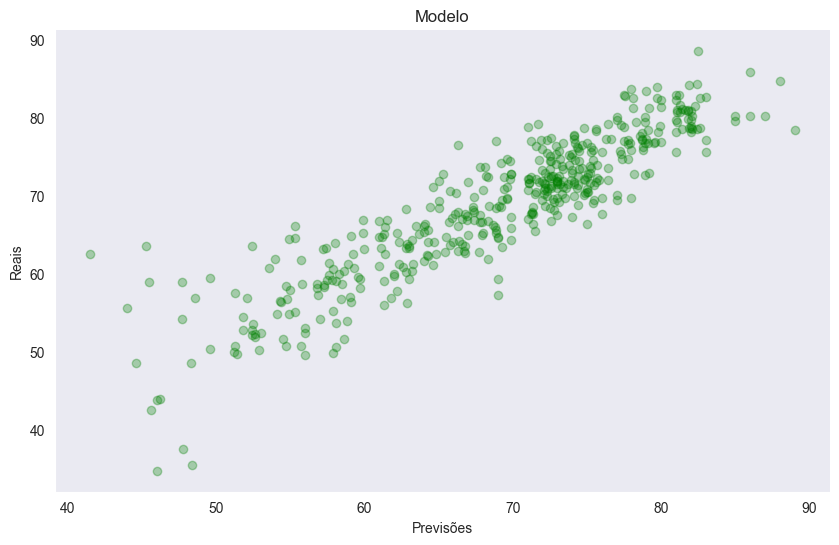

In [95]:
# Plot das previsões
cria_scatter(df_previsoes.Valor_Real, df_previsoes.Valor_Previsto, 'Modelo', 'Previsões', 'Reais')

> Na análise exploratória no início do Lab vimos que a maioria dos dados tinha exptectativa de vida entre 70 e 80 anos, extamente onde a performance do modelo foi melhor (porque havia mais dados de exemplo).

In [96]:
# Print das métricas com dados de teste
print('Mean Absolute Error:', metrics.mean_absolute_error(y_teste, y_pred_teste))
print('Mean Squared Error:', metrics.mean_squared_error(y_teste, y_pred_teste))
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_teste, y_pred_teste)))
print('R2 Score:', metrics.r2_score(y_teste, y_pred_teste))

Mean Absolute Error: 3.0672174839282507
Mean Squared Error: 16.65428828839155
Root Mean Squared Error: 4.080966587512271
R2 Score: 0.8090460243016727


"Erro médio quadrático" (MSE) é talvez a métrica mais popular usada para problemas de regressão. Essencialmente, encontra o erro quadrado médio entre os valores previstos e reais.

Temos um modelo de regressão que prevê a expectativa de vida (definido como ŷᵢ) e temos ainda a expectativa de vida real (indicada com y). Então o MSE pode ser calculado como:

<img src="imagens/mse.png" alt="Drawing" style="width: 400px;"/>

Às vezes, usamos o RMSE para ter uma métrica com escala como os valores-alvo, que é essencialmente a raiz quadrada do MSE.

O erro absoluto médio (ou desvio absoluto médio) é outra métrica que encontra a distância absoluta média entre os valores previsto e alvo. O MAE é definido como abaixo:

<img src="imagens/mae.png" alt="Drawing" style="width: 400px;"/>

O R2 é o coeficiente de determinação, sendo calculado pela fórmula abaixo:

<img src="imagens/rsquared.png" alt="Drawing" style="width: 400px;"/>

## Previsão com Novos Dados

In [98]:
# Carregando os novos dados
novos_dados = pd.read_csv('novos_dados_aula20.csv')

In [99]:
novos_dados

,adult_mortality,diphtheria,hiv,gdp,thinness_till19,school
0,252,63,0.1,690,18.3,9.8


In [100]:
# Os novos dados precisam ser padronizados
novos_dados_scaled = scaler.transform(novos_dados)

In [101]:
novos_dados_scaled

array([[ 0.62834533, -0.77692878, -0.35804767, -0.44944495,  2.90215024,
        -0.70250318]])

In [102]:
# Previsão
previsao = modelo_lr_v1.predict(novos_dados_scaled)

In [103]:
print('Esse país teria cidadãos com uma expectativa de vida (em anos) de aproximadamente:', previsao)

Esse país teria cidadãos com uma expectativa de vida (em anos) de aproximadamente: [[62.40911806]]


# Fim